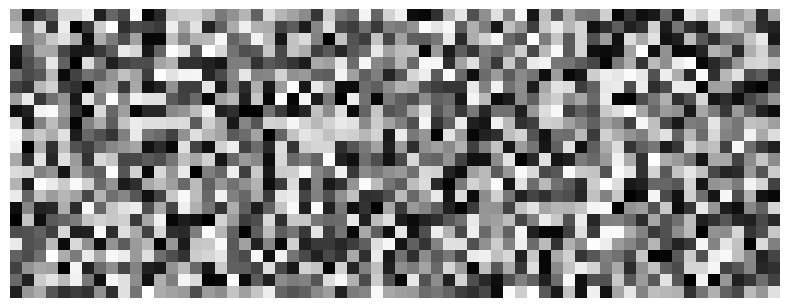

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1536 cells — factor pairs close to square: 32 x 48
n_rows, n_cols = 24, 64
np.random.seed(42)
latent = np.random.rand(n_rows, n_cols)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.imshow(latent, cmap='gray_r', vmin=0, vmax=1, aspect='equal', interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
# ax.set_title('Mock Latent Representation (1536-dim)', fontsize=13, pad=10)
plt.tight_layout()
plt.show()


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

## Demo reconstruction plot

In [35]:
timestamps = np.linspace(0,10,25)
flux = 0.5 * np.sin(timestamps) + 0.5 * np.random.normal(0,1,size=timestamps.shape)
flux_err = np.abs(0.5 * np.random.normal(1,1,size=timestamps.shape))

### Forward

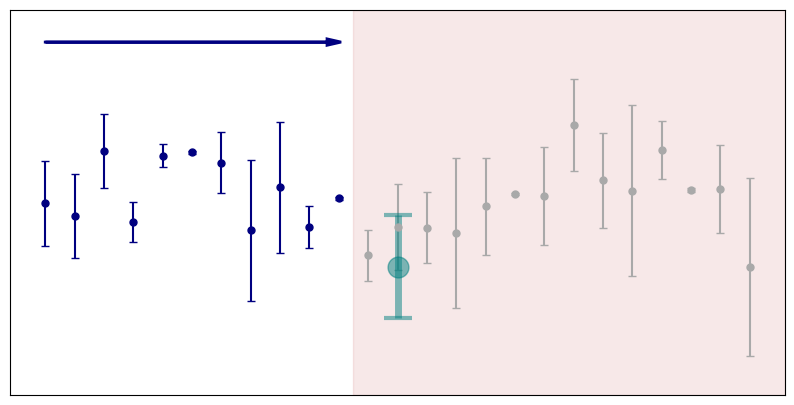

In [253]:
rect = patches.Rectangle(
    (4.375, -3),        # (x0, y0) lower-left corner
    10.5 - 4.375,       # width
    3 - (-3),       # height
    color='firebrick',
    alpha=0.1
)

plt.figure(figsize=(10,5))
plt.errorbar(timestamps[0:11], flux[0:11], yerr=flux_err[0:11], fmt='o', color='navy',ecolor='navy', capsize=3,markersize=5)
plt.errorbar(timestamps[11:], flux[11:], yerr=flux_err[11:], fmt='o', color='darkgrey',ecolor='darkgrey', capsize=3,markersize=5)
plt.errorbar(5,-1, yerr=0.8, fmt='o', color='teal',ecolor='teal', capsize=10,markersize=15,alpha=0.5,elinewidth=5,capthick=3)
plt.gca().add_patch(rect)

# plt.text(0.45,2.35,'forward training input', fontsize=16, color='white',
#         bbox=dict(
#         boxstyle='round',     # e.g. 'round', 'square', 'round,pad=0.3'
#         facecolor='navy',
#         edgecolor='navy',
#         alpha=1
#     )
# )
plt.arrow(0, 2.5, 4,0, head_width=0.1, head_length=0.2, fc='navy', ec='navy',linewidth=2)

# plt.text(6,-2.3,'masked from training', fontsize=16, color='firebrick')
# plt.text(5,2.3,'prediction from forward training', fontsize=16, color='teal',
#          bbox=dict(
#              boxstyle='round',
#              facecolor='white',
#              edgecolor='teal',
#              alpha=1
#          ))

# plt.arrow(5.8, 2.1, -0.69, -2.8, head_width=0.1, head_length=0.2, fc='teal', ec='teal')

# plt.xlabel(r'time $\rightarrow$', fontsize=16)
# plt.ylabel('flux', fontsize=16)
plt.ylim(-3,3)
plt.xlim(-0.5,10.5)
plt.yticks([])  # Hide y-axis ticks
plt.xticks([])
plt.show()

### Backward

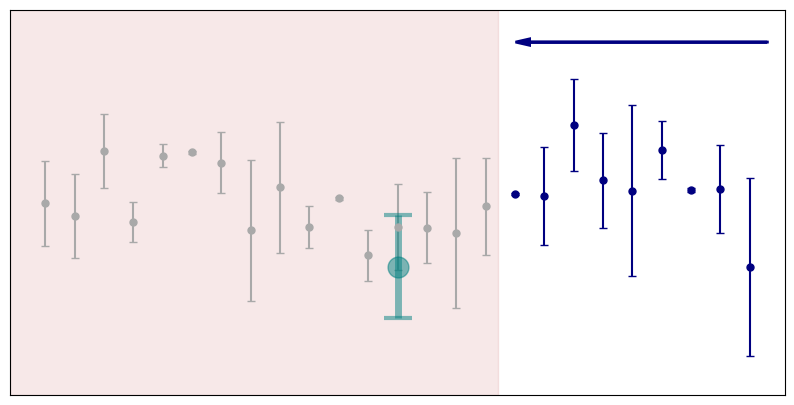

In [251]:
rect = patches.Rectangle(
    (-0.5, -3),        # (x0, y0) lower-left corner
    10.5 - 3.575,       # width
    3 - (-3),       # height
    color='firebrick',
    alpha=0.1
)

plt.figure(figsize=(10,5))
plt.errorbar(timestamps[16:], flux[16:], yerr=flux_err[16:], fmt='o', color='navy',ecolor='navy', capsize=3,markersize=5)
plt.errorbar(timestamps[0:16], flux[0:16], yerr=flux_err[0:16], fmt='o', color='darkgrey',ecolor='darkgrey', capsize=3,markersize=5)
plt.errorbar(5,-1, yerr=0.8, fmt='o', color='teal',ecolor='teal', capsize=10,markersize=15,alpha=0.5,elinewidth=5,capthick=3)
plt.gca().add_patch(rect)

# plt.text(7.8,2.2,'training input', fontsize=20, color='navy',
#         bbox=dict(
#         boxstyle='round',     # e.g. 'round', 'square', 'round,pad=0.3'
#         facecolor='navy',
#         edgecolor='navy',
#         alpha=0.1
#     )
# )
plt.arrow(10.25, 2.5, -3.375
          ,0, head_width=0.1, head_length=0.2, fc='navy', ec='navy',linewidth=2)

# plt.text(0.5,-2.3,'masked', fontsize=20, color='firebrick')
# plt.text(1,2.3,'prediction', fontsize=20, color='teal',
#          bbox=dict(
#              boxstyle='round',
#              facecolor='white',
#              edgecolor='teal',
#              linewidth=2,
#              alpha=1
#          ))
# plt.arrow(2, 2.1, 2.7, -2.8, head_width=0.2, head_length=0.3, fc='teal', ec='teal',linewidth=2)

# plt.xlabel(r'time $\rightarrow$', fontsize=24)
# plt.ylabel('flux', fontsize=24)
plt.ylim(-3,3)
plt.xlim(-0.5,10.5)
plt.yticks([])  # Hide y-axis ticks
plt.xticks([])
plt.show()

### Residuals Comparison

In [16]:
age_test_folder = '../output/age_predictor_tests/'

gyro = pd.read_csv(age_test_folder + 'gyro-nle-v1/kfold_predictions.csv')
# baseline = pd.read_csv(age_test_folder + 'baseline-multiscale/kfold_predictions.csv')
# unet = pd.read_csv(age_test_folder + 'unet-multiscale/kfold_predictions.csv')
# lw_conv = pd.read_csv(age_test_folder + 'lightweight_conv-multiscale/kfold_predictions.csv')
# stellar_props = pd.read_csv(age_test_folder + 'stellar_props-multiscale/kfold_predictions.csv')
# props_unet = pd.read_csv(age_test_folder + 'props_unet-multiscale/kfold_predictions.csv')
# long_curve = pd.read_csv(age_test_folder + 'long_curve-multiscale/kfold_predictions.csv')
# baseline_long = pd.read_csv(age_test_folder + 'baseline-long-multiscale/kfold_predictions.csv')
cf_final = pd.read_csv(age_test_folder + 'FINAL-pca4-v18-multiscale-latent_max-pca/kfold_predictions.csv')

scatter_gyro = np.nanstd(gyro['residual_dex'])
# scatter_baseline = np.nanstd(baseline['log_residual'])
# scatter_unet = np.nanstd(unet['log_residual'])
# scatter_lw_conv = np.nanstd(lw_conv['log_residual'])
# scatter_stellar_props = np.nanstd(stellar_props['log_residual'])
# scatter_props_unet = np.nanstd(props_unet['log_residual'])
# scatter_long_curve = np.nanstd(long_curve['log_residual'])
# scatter_baseline_long = np.nanstd(baseline_long['log_residual'])
scatter_cf_final = np.nanstd(cf_final['residual_dex'])

### Make aggregation by star

In [44]:
long_curve_agg = pd.DataFrame(columns=long_curve.columns)
long_curve_agg.drop(columns=['fold'], inplace=True)

for tic in long_curve['TIC_ID'].unique():
    subset = long_curve[long_curve['TIC_ID'] == tic]
    true_age = subset['true_age_myr'].iloc[0]
    bprp0 = subset['bprp0'].iloc[0]
    predicted_age = 10**np.log10(subset['predicted_age_myr']).mean()
    log_residual = np.log10(predicted_age) - np.log10(true_age)
    record = {
        'TIC_ID': tic,
        'true_age_myr': true_age,
        'predicted_age_myr': predicted_age,
        'log_residual': log_residual,
        'bprp0': bprp0
    }
    long_curve_agg = pd.concat([long_curve_agg, pd.DataFrame([record])], ignore_index=True)

/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_40507/3901468151.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  long_curve_agg = pd.concat([long_curve_agg, pd.DataFrame([record])], ignore_index=True)


In [45]:
long_curve_agg

,TIC_ID,true_age_myr,predicted_age_myr,bprp0,log_residual
0,405461319,97.00,131.597147,1.023294,0.132475
1,456945485,775.00,640.708671,0.900964,-0.082641
2,118677684,775.00,134.379376,3.136167,-0.760969
3,118681038,2.49,90.938508,1.554253,1.562548
4,456946694,6.22,67.953790,1.016821,1.038423
...,...,...,...,...,...
2489,35154685,97.00,149.619798,1.062559,0.188217
2490,46678194,97.00,94.457655,2.117883,-0.011535
2491,427546152,97.00,121.266943,1.707976,0.096971
2492,46632137,97.00,162.048217,1.686312,0.222873


## Residuals Histogram

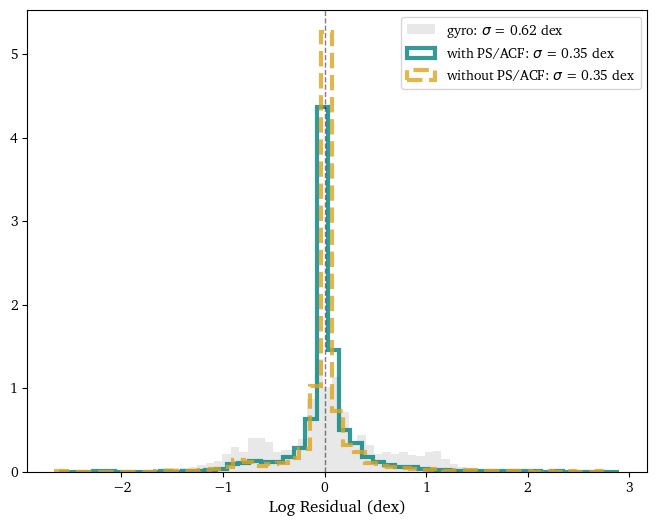

In [ ]:
plt.figure(figsize=(8, 6))

plt.hist(gyro['log_residual'], bins=50, alpha=0.5, label=r'gyro: $\sigma$ = {:.2f} dex'.format(scatter_gyro), color='lightgrey',density=True)
# plt.hist(baseline['log_residual'], bins=50, label=r'baseline: $\sigma$ = {:.2f} dex'.format(scatter_baseline), color='magenta',density=True,
#          histtype='step',edgecolor='magenta',linewidth=1, alpha=1)
# plt.hist(unet['log_residual'], bins=50, label=r'UNet: $\sigma$ = {:.2f} dex'.format(scatter_unet), color='cyan',density=True,
#          histtype='step',edgecolor='cyan',linewidth=1, alpha=1)
# plt.hist(lw_conv['log_residual'], bins=50, label=r'Lightweight Conv: $\sigma$ = {:.2f} dex'.format(scatter_lw_conv), color='orange',density=True,
#          histtype='step',edgecolor='orange',linewidth=1, alpha=1)
# plt.hist(stellar_props['log_residual'], bins=50, label=r'Stellar Props: $\sigma$ = {:.2f} dex'.format(scatter_stellar_props), color='green',density=True,
#          histtype='step',edgecolor='green',linewidth=1, alpha=1)
# plt.hist(props_unet['log_residual'], bins=50, label=r'Props + UNet: $\sigma$ = {:.2f} dex'.format(scatter_props_unet), color='blue',density=True,
#          histtype='step',edgecolor='blue',linewidth=1, alpha=1)
plt.hist(long_curve['log_residual'], bins=50, label=r'with PS/ACF: $\sigma$ = {:.2f} dex'.format(scatter_long_curve), color='teal',density=True,
         histtype='step',edgecolor='teal',linewidth=3, alpha=0.8)
plt.hist(baseline_long['log_residual'], bins=50, label=r'without PS/ACF: $\sigma$ = {:.2f} dex'.format(scatter_baseline_long), color='goldenrod',density=True,
         histtype='step',edgecolor='goldenrod',linewidth=3, alpha=0.8,linestyle='--')
# plt.hist(cf_final['log_residual'], bins=50, label=r'CF-final: $\sigma$ = {:.2f} dex'.format(scatter_cf_final), color='brown',density=True,
#          histtype='step',edgecolor='brown',linewidth=1, alpha=1)

plt.xlabel('Log Residual (dex)', fontsize=12)
# plt.ylabel('Density', fontsize=12)
# plt.title('Age Prediction Residuals (Aggregated by TIC_ID)', fontsize=14)
plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.show()

## Plot over Prot/Age/Colour

### Colour

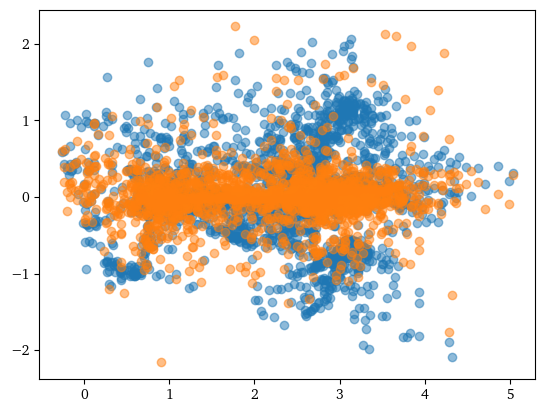

In [46]:
plt.plot((gyro['bprp0']), gyro['log_residual'], 'o', label='gyro', alpha=0.5)
plt.plot(long_curve_agg['bprp0'], long_curve_agg['log_residual'], 'o', label='long curve', alpha=0.5)
plt.show()

### Inferred Age

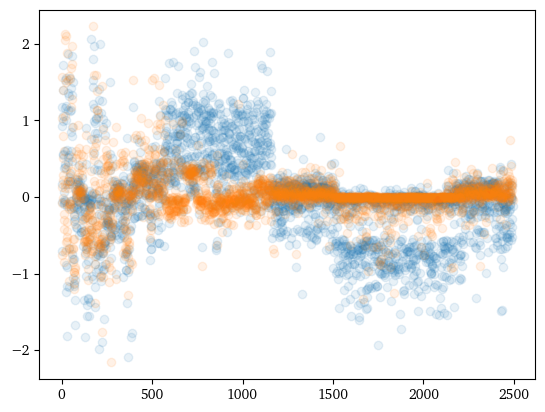

In [48]:
log_pred_age_gyro = np.log10(gyro.sort_values('predicted_age_myr')['predicted_age_myr'])
res_gyro = gyro.sort_values('predicted_age_myr')['log_residual']
log_pred_age_long = np.log10(long_curve_agg.sort_values('predicted_age_myr')['predicted_age_myr'])
res_long = long_curve_agg.sort_values('predicted_age_myr')['log_residual']
plt.plot(res_gyro, 'o', label='gyro', alpha=0.1)
plt.plot(res_long, 'o', label='long curve', alpha=0.1)
plt.show()

## Combined Plot

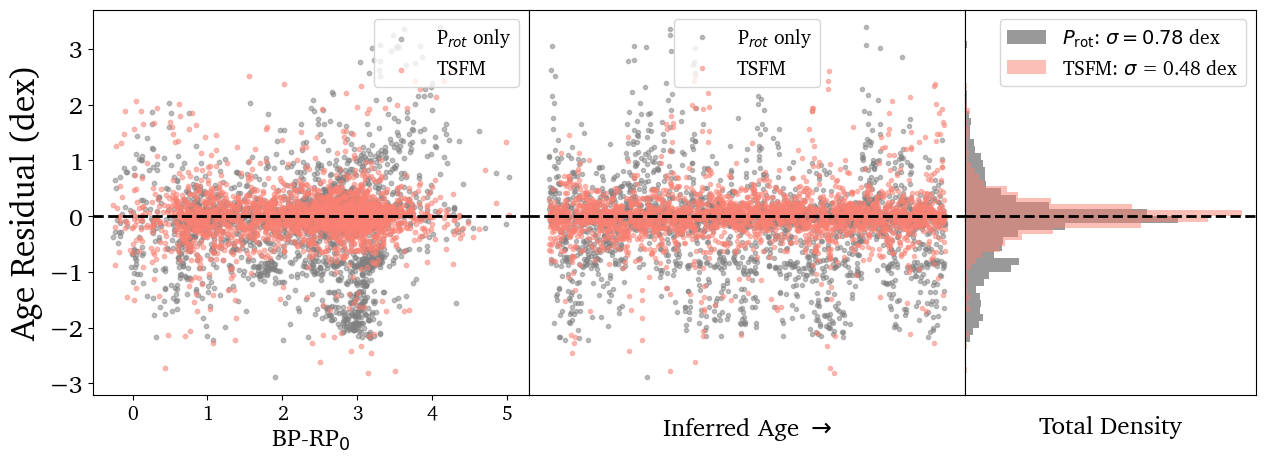

In [11]:
fig = plt.figure(figsize=(15,5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3, 3, 2],wspace=0) 

# Comparison over bprp0
ax0 = fig.add_subplot(gs[0])
ax0.scatter((gyro['bprp0']), gyro['residual_dex'], label=r'P$_{rot}$ only', alpha=0.5,s=10,color='grey')
ax0.scatter(cf_final['bprp0'], cf_final['residual_dex'],
            label='TSFM',alpha=0.5,s=10,color='salmon')
ax0.axhline(0, color='k', linestyle='--', linewidth=2, alpha=1)
ax0.set_ylabel('Age Residual (dex)', fontsize=24)
ax0.tick_params(axis='y', labelsize=18)
ax0.set_xlabel(r'BP-RP$_0$', fontsize=18)
ax0.tick_params(axis='x', labelsize=14)
ax0.legend(fontsize=14,loc='upper right')

# Comparison over inferred age
ax1 = fig.add_subplot(gs[1])
log_pred_age_gyro = np.log10(gyro.sort_values(['pred_median', 'gaia_id'])['pred_median'])
res_gyro = gyro.sort_values(['pred_median', 'gaia_id'])['residual_dex']
log_pred_age_long = np.log10(cf_final.sort_values(['log10_pred_median', 'TIC_ID'])['log10_pred_median'])
res_long = cf_final.sort_values(['log10_pred_median', 'TIC_ID'])['residual_dex']
ax1.plot(res_gyro, 'o', label=r'P$_{rot}$ only', alpha=0.5,color='grey',markersize=3)
ax1.plot(res_long, 'o', label='TSFM', alpha=0.5,color='salmon',markersize=3)
ax1.axhline(0, color='k', linestyle='--', linewidth=2, alpha=1)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.set_xlabel(r'Inferred Age $\rightarrow$', fontsize=18,labelpad=15)
ax1.legend(fontsize=14)

# Histogram of residuals
ax2 = fig.add_subplot(gs[2])
scatter_gyro = np.nanstd(gyro['residual_dex'])
scatter_long_curve = np.nanstd(cf_final['residual_dex'])
ax2.hist(gyro['residual_dex'], bins=50, alpha=0.8, color='grey',
         density=True,orientation='horizontal',
         label=fr'$P_{{\rm rot}}$: $\sigma = {scatter_gyro:.2f}$ dex',
         linewidth=3)
ax2.hist(cf_final['residual_dex'], bins=50,
         color='salmon',density=True,
         linewidth=3, alpha=0.5,orientation='horizontal',label=r'TSFM: $\sigma$ = {:.2f} dex'.format(scatter_long_curve))
ax2.axhline(0, color='k', linestyle='--', linewidth=2, alpha=1)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_xlabel('Total Density', fontsize=18,labelpad=15)
ax2.legend(fontsize=14,loc='upper right')
plt.show()

## Precision/Accuracy Grids

### Helper functions

In [12]:
def getAvgPrecision(df,bw_age,bw_bprp,bin_age,bin_bprp):
    sub_df = df.loc[(df['pred_median'] >= bin_age-bw_age/2) &
                     (df['pred_median'] < bin_age+bw_age/2) &
                     (df['bprp0'] >= bin_bprp-bw_bprp/2) &
                     (df['bprp0'] < bin_bprp+bw_bprp/2)]
    avg_err_1sig_low = np.nanmean(sub_df['pred_median'] - sub_df['pred_p16'])
    avg_err_1sig_high = np.nanmean(sub_df['pred_p84'] - sub_df['pred_median'])
    avg_err = np.nanmean([avg_err_1sig_low,avg_err_1sig_high])
    return [avg_err,avg_err_1sig_low,avg_err_1sig_high]

In [13]:
def getAvgRes(df,bw_age,bw_bprp,bin_age,bin_bprp):
    sub_df = df.loc[(df['pred_median'] >= bin_age-bw_age/2) &
                     (df['pred_median'] < bin_age+bw_age/2) &
                     (df['bprp0'] >= bin_bprp-bw_bprp/2) &
                     (df['bprp0'] < bin_bprp+bw_bprp/2)]
    avg_res = np.nanmean(sub_df['residual_dex'])
    return avg_res

### Get average precision

In [17]:
# Plot average precision as a function of inferred age and colour

bprp_min = 0.3
bprp_max = 3.5
logA_Myr_min = 0
logA_Myr_max = 4

bprp_bins = np.linspace(bprp_min,bprp_max,320)
logA_Myr_bins = np.linspace(logA_Myr_min,logA_Myr_max,400)

# Gyro

gyro_avg_prec_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))
gyro_avg_prec_1sig_high_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))
gyro_avg_prec_1sig_low_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))

for i in range(len(logA_Myr_bins)-1):
    for j in range(len(bprp_bins)-1):
        [gyro_avg_prec_matrix[i, j],gyro_avg_prec_1sig_low_matrix[i,j],
         gyro_avg_prec_1sig_high_matrix[i,j]] = getAvgPrecision(gyro,0.2, 0.2, bprp_bins[j],logA_Myr_bins[i])
        

# Latent

latent_avg_prec_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))
latent_avg_prec_1sig_high_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))
latent_avg_prec_1sig_low_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))

for i in range(len(logA_Myr_bins)-1):
    for j in range(len(bprp_bins)-1):
        [latent_avg_prec_matrix[i, j],latent_avg_prec_1sig_low_matrix[i,j],
         latent_avg_prec_1sig_high_matrix[i,j]] = getAvgPrecision(cf_final,0.2, 0.2, bprp_bins[j],logA_Myr_bins[i])
        
# np.save(data_folder + 'avg_err_matrix.npy',avg_err_matrix)
# np.save(data_folder + 'avg_err_1sig_low_matrix.npy',avg_err_1sig_low_matrix)
# np.save(data_folder + 'avg_err_1sig_high_matrix.npy',avg_err_1sig_high_matrix)


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_8246/917003514.py:6: RuntimeWarning: Mean of empty slice
  avg_err_1sig_low = np.nanmean(sub_df['pred_median'] - sub_df['pred_p16'])
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_8246/917003514.py:7: RuntimeWarning: Mean of empty slice
  avg_err_1sig_high = np.nanmean(sub_df['pred_p84'] - sub_df['pred_median'])
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_8246/917003514.py:8: RuntimeWarning: Mean of empty slice
  avg_err = np.nanmean([avg_err_1sig_low,avg_err_1sig_high])


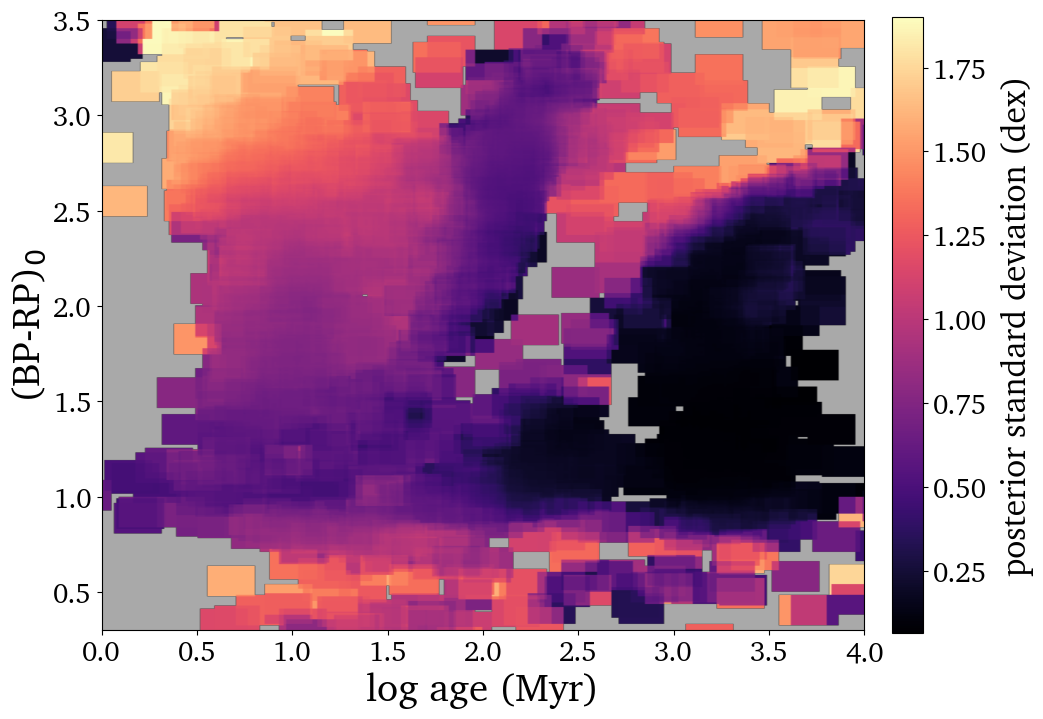

In [20]:

from matplotlib.patches import Rectangle

plt.figure(figsize=(12,8))

# Add background rectangle
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey',zorder=-100)
plt.gca().add_patch(rect)

# Plot the heatmap using imshow
plt.imshow(gyro_avg_prec_matrix, cmap='magma', origin='lower',
           extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
cbar = plt.colorbar(pad=0.03)
cbar.set_label('posterior standard deviation (dex)', fontsize=24,labelpad=10)
cbar.ax.tick_params(labelsize=20)
# plt.title('Average Precision as a Function of Inferred Age and Colour',fontsize=16)
plt.ylabel(r'(BP-RP)$_0$',fontsize=28)
plt.xlabel('log age (Myr)',fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.savefig(fig_folder + 'avg_precision_matrix.png',bbox_inches='tight', pad_inches=0)
plt.show()

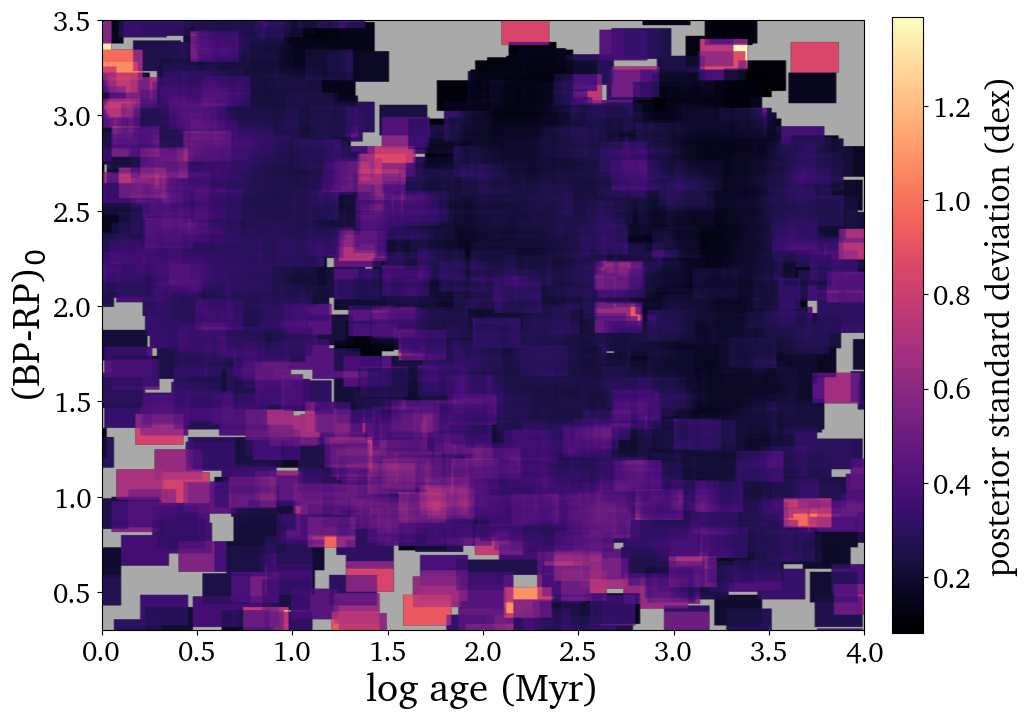

In [19]:

from matplotlib.patches import Rectangle

plt.figure(figsize=(12,8))

# Add background rectangle
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey',zorder=-100)
plt.gca().add_patch(rect)

# Plot the heatmap using imshow
plt.imshow(latent_avg_prec_matrix, cmap='magma', origin='lower',
           extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
cbar = plt.colorbar(pad=0.03)
cbar.set_label('posterior standard deviation (dex)', fontsize=24,labelpad=10)
cbar.ax.tick_params(labelsize=20)
# plt.title('Average Precision as a Function of Inferred Age and Colour',fontsize=16)
plt.ylabel(r'(BP-RP)$_0$',fontsize=28)
plt.xlabel('log age (Myr)',fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.savefig(fig_folder + 'avg_precision_matrix.png',bbox_inches='tight', pad_inches=0)
plt.show()

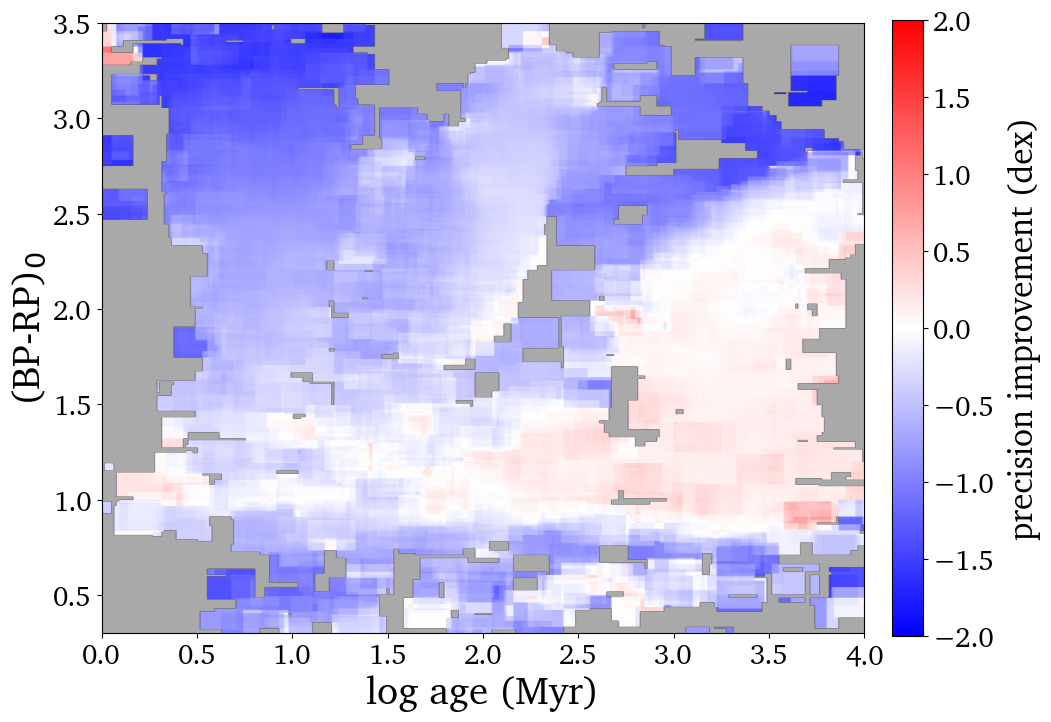

In [31]:
prec_diff_matrix = latent_avg_prec_matrix - gyro_avg_prec_matrix
plt.figure(figsize=(12,8))

# Add background rectangle
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey',zorder=-100)
plt.gca().add_patch(rect)

# Plot the heatmap using imshow
plt.imshow(prec_diff_matrix, cmap='bwr', origin='lower',vmin=-2,vmax=2,
           extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
cbar = plt.colorbar(pad=0.03)
cbar.set_label('precision improvement (dex)', fontsize=24,labelpad=10)
cbar.ax.tick_params(labelsize=20)
# plt.title('Average Precision as a Function of Inferred Age and Colour',fontsize=16)
plt.ylabel(r'(BP-RP)$_0$',fontsize=28)
plt.xlabel('log age (Myr)',fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.savefig(fig_folder + 'avg_precision_matrix.png',bbox_inches='tight', pad_inches=0)
plt.show()

### Get average residual

In [23]:
# Get average residual as a function of inferred age and colour

bprp_min = 0.3
bprp_max = 3.5
logA_Myr_min = 0
logA_Myr_max = 4

bprp_bins = np.linspace(bprp_min,bprp_max,320)
logA_Myr_bins = np.linspace(logA_Myr_min,logA_Myr_max,400)

gyro_avg_res_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))
latent_avg_res_matrix = np.zeros((len(logA_Myr_bins) - 1, len(bprp_bins) - 1))

for i in range(len(logA_Myr_bins)-1):
    for j in range(len(bprp_bins)-1):
        gyro_avg_res_matrix[i, j] = getAvgRes(gyro, 0.2, 0.2, bprp_bins[j],logA_Myr_bins[i])

for i in range(len(logA_Myr_bins)-1):
    for j in range(len(bprp_bins)-1):
        latent_avg_res_matrix[i, j] = getAvgRes(cf_final, 0.2, 0.2, bprp_bins[j],logA_Myr_bins[i])

# np.save(data_folder + 'gyro_avg_res_matrix.npy',gyro_avg_res_matrix)


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_8246/4281927.py:6: RuntimeWarning: Mean of empty slice
  avg_res = np.nanmean(sub_df['residual_dex'])


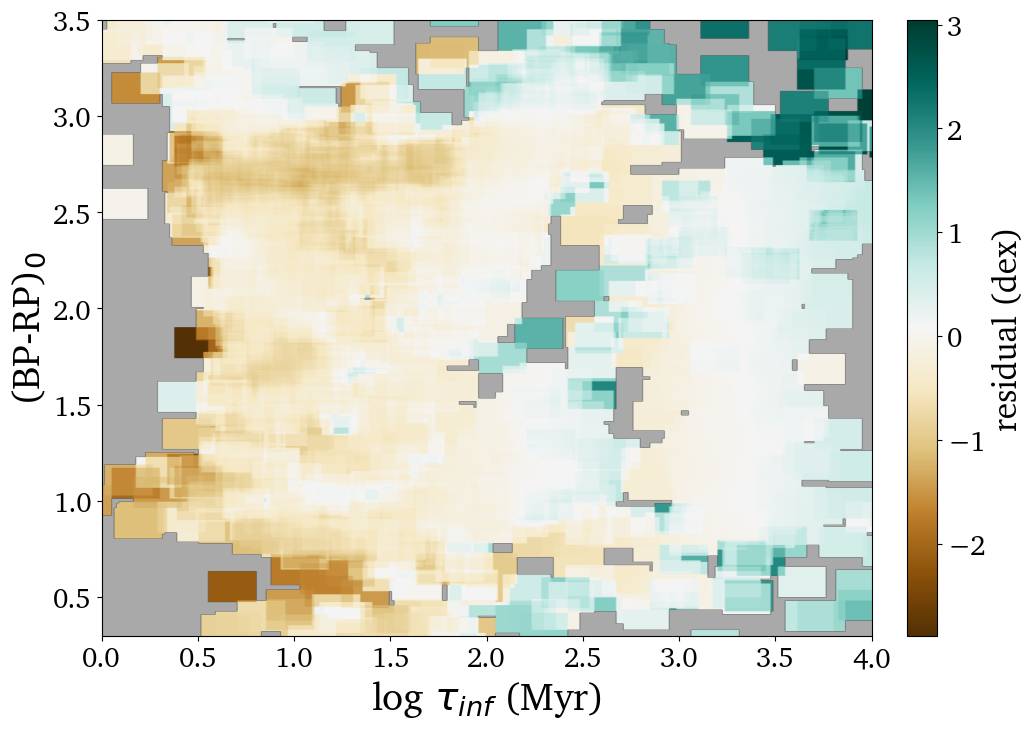

In [24]:

plt.figure(figsize=(15,8))

# Add background rectangle
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey',zorder=-100)
plt.gca().add_patch(rect)

# Plot the heatmap using imshow
plt.imshow(gyro_avg_res_matrix, cmap='BrBG', origin='lower',
           extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
cbar=plt.colorbar(pad=0.03)
# plt.title('Average Residual as a Function of Inferred Age and Colour',fontsize=16)
cbar.set_label('residual (dex)', fontsize=24)

# Set the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=20)

plt.ylabel(r'(BP-RP)$_0$',fontsize=28)
plt.xlabel(r'log $\tau_{inf}$ (Myr)',fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()



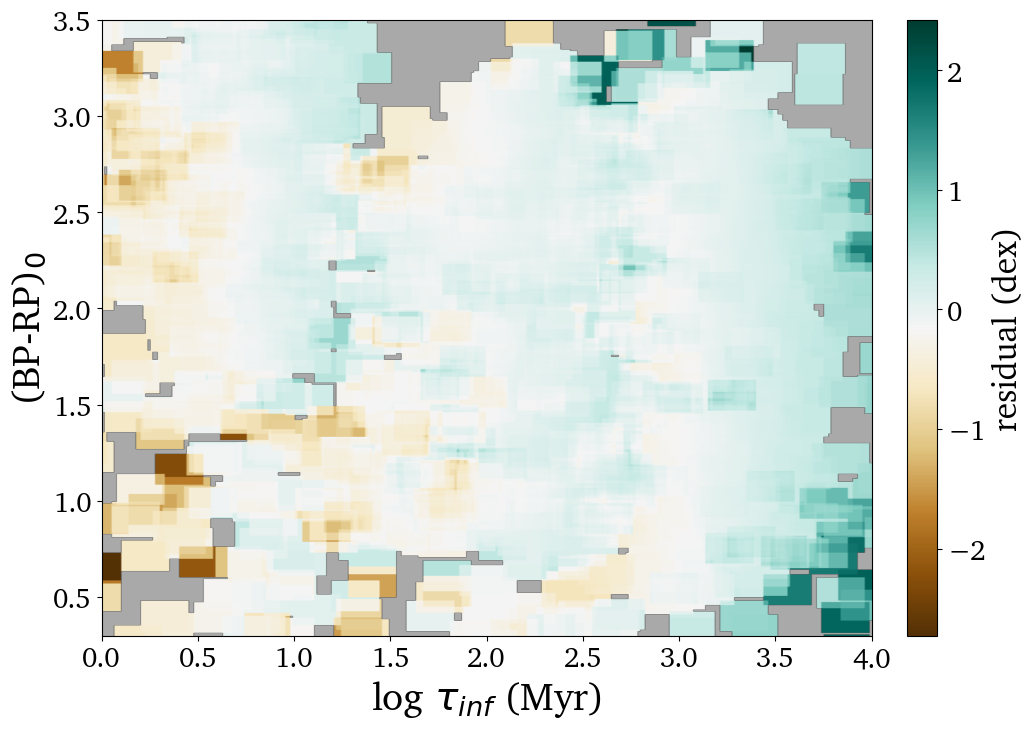

In [27]:

plt.figure(figsize=(15,8))

# Add background rectangle
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey',zorder=-100)
plt.gca().add_patch(rect)

# Plot the heatmap using imshow
plt.imshow(latent_avg_res_matrix, cmap='BrBG', origin='lower',
           extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
cbar=plt.colorbar(pad=0.03)
# plt.title('Average Residual as a Function of Inferred Age and Colour',fontsize=16)
cbar.set_label('residual (dex)', fontsize=24)

# Set the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=20)

plt.ylabel(r'(BP-RP)$_0$',fontsize=28)
plt.xlabel(r'log $\tau_{inf}$ (Myr)',fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()



#### Difference in average residual

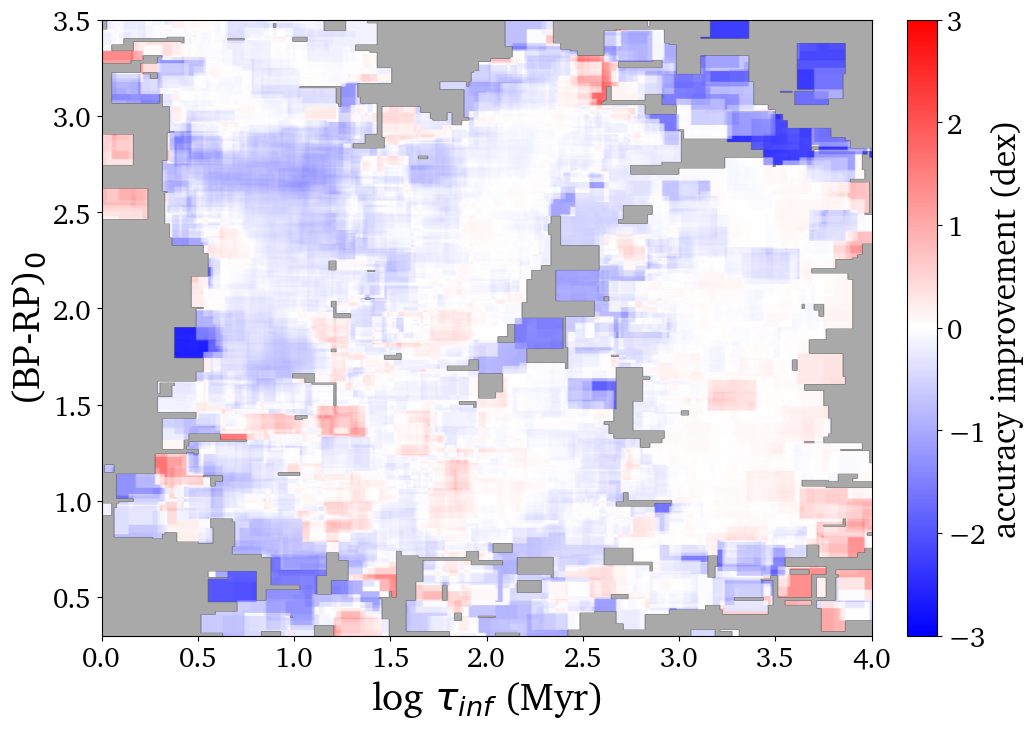

In [32]:
abs_gyro_avg_res_matrix = np.abs(gyro_avg_res_matrix)
abs_latent_avg_res_matrix = np.abs(latent_avg_res_matrix)
res_diff_matrix = abs_latent_avg_res_matrix - abs_gyro_avg_res_matrix
plt.figure(figsize=(15,8))
# Add background rectangle
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey',zorder=-100)
plt.gca().add_patch(rect)

# Plot the heatmap using imshow
plt.imshow(res_diff_matrix, cmap='bwr', origin='lower',vmin=-3,vmax=3,
           extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
cbar=plt.colorbar(pad=0.03)
# plt.title('Average Residual as a Function of Inferred Age and Colour',fontsize=16)
cbar.set_label('accuracy improvement (dex)', fontsize=24)

# Set the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=20)

plt.ylabel(r'(BP-RP)$_0$',fontsize=28)
plt.xlabel(r'log $\tau_{inf}$ (Myr)',fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

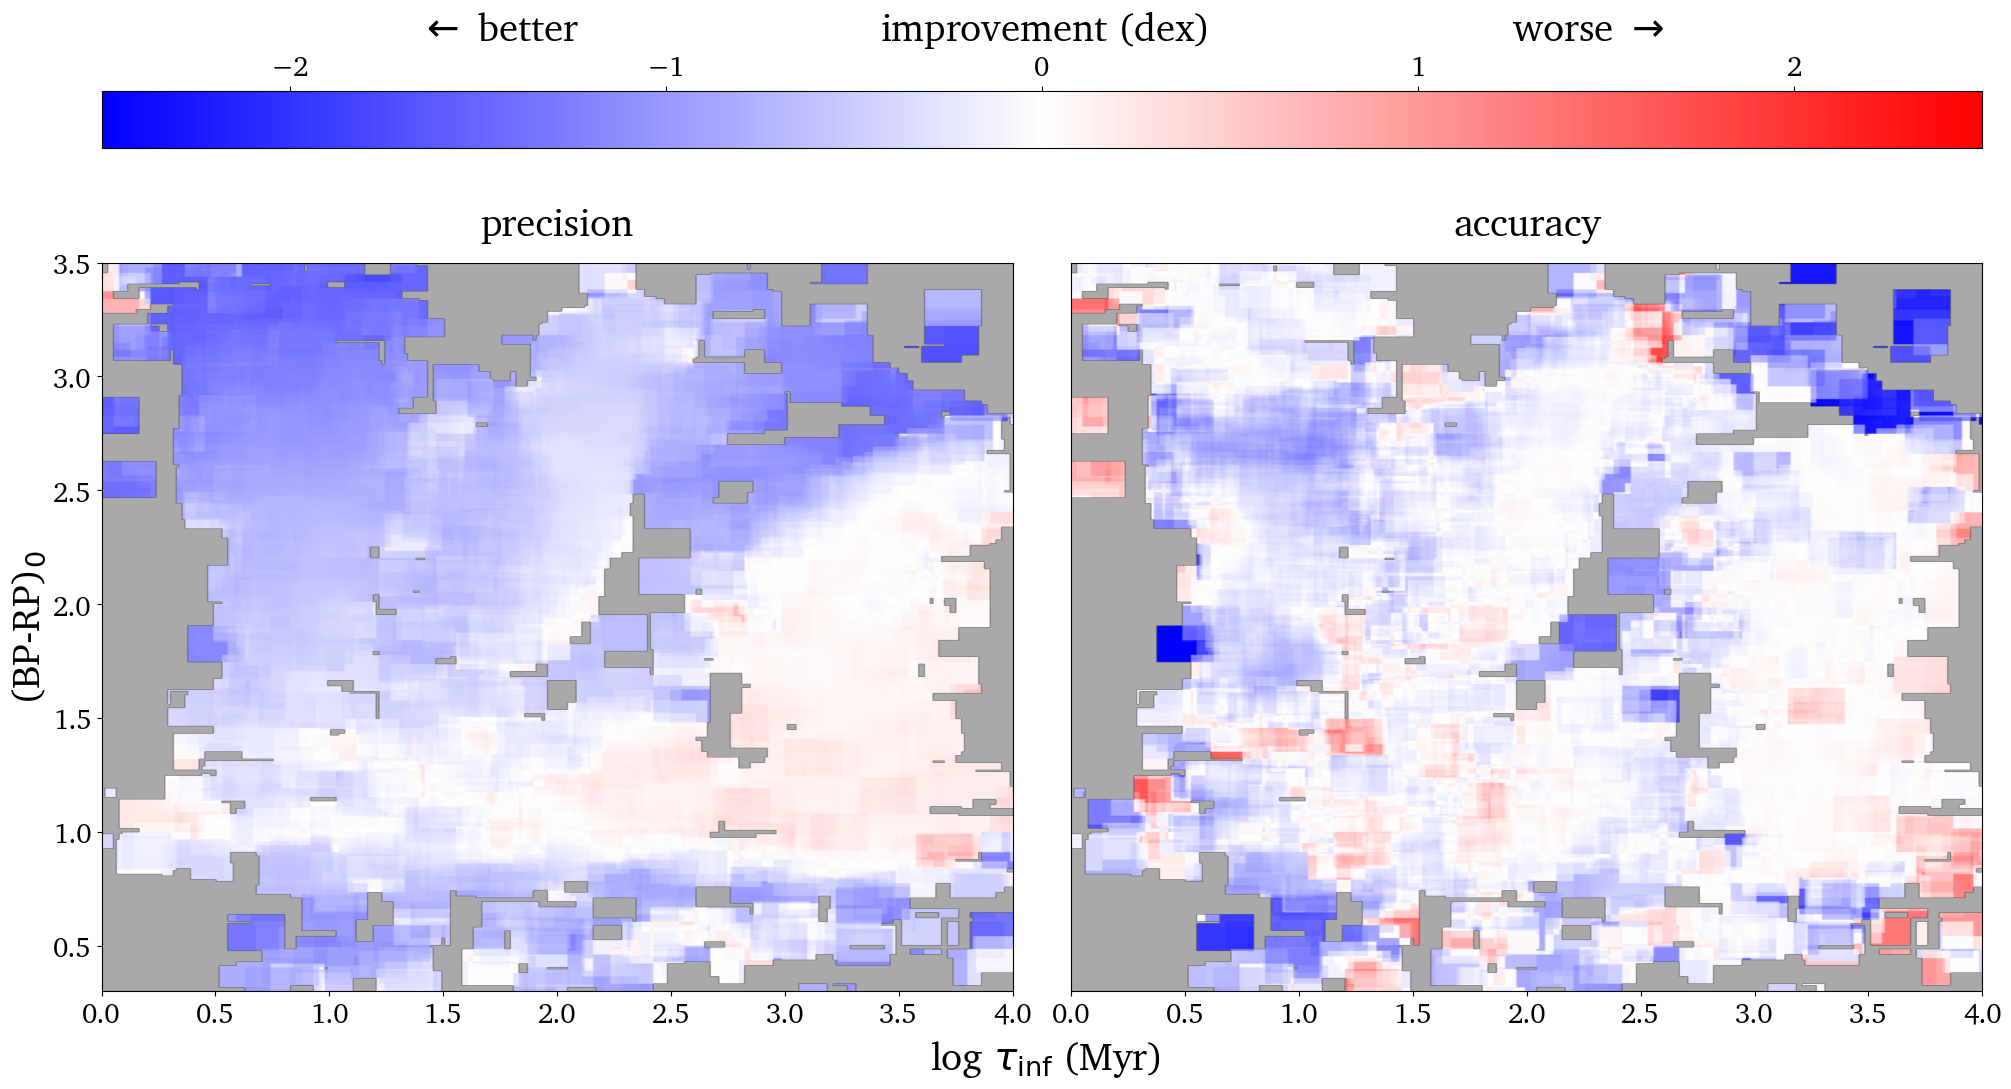

In [115]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)

vmin, vmax = -2.5, 2.5

# Left: precision improvement
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey', zorder=-100)
ax0.add_patch(rect)
im0 = ax0.imshow(prec_diff_matrix, cmap='bwr', origin='lower', vmin=vmin, vmax=vmax,
                 extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
ax0.set_ylabel(r'(BP-RP)$_0$', fontsize=28)
ax0.tick_params(axis='both', labelsize=20)
ax0.set_title('precision', fontsize=28, pad=20)

# Right: accuracy improvement
rect = Rectangle((0, 0.3), 4, 3.2, linewidth=1, edgecolor=None, facecolor='darkgrey', zorder=-100)
ax1.add_patch(rect)
im1 = ax1.imshow(res_diff_matrix, cmap='bwr', origin='lower', vmin=vmin, vmax=vmax,
                 extent=[logA_Myr_min, logA_Myr_max, bprp_min, bprp_max])
ax1.tick_params(axis='both', labelsize=20)
ax1.set_yticks([])
ax1.set_title('accuracy', fontsize=28, pad=20)

# Shared x-axis label
fig.supxlabel(r'log $\tau_{\rm inf}$ (Myr)', fontsize=28, y=-0.08, x = 0.52)

# Single shared colorbar spanning both subplots
cbar = fig.colorbar(im0, ax=[ax0, ax1], location='top', pad=0.08,
                    fraction=0.08, aspect=33)
cbar.set_label(r'$\leftarrow$ better                            improvement (dex)                            worse $\rightarrow$', fontsize=28, labelpad=10)
cbar.ax.tick_params(labelsize=20)

plt.show()